In [2]:
import open3d as o3d
import os
import cv2
import subprocess
import numpy as np
from util import (
    auto_select_sam3_prompt,
    flip_uv_v_inplace,
    save_sam_masks_multi_frames,
    select_viewpoints,
    render_mesh_materials,
    render_mesh_texture,
    load_masks_for_mesh_frame,
    fuse_views_to_face_mask,
    build_face_adjacency,
    build_local_band_around_dynamic,
    local_expand_dynamic,
    split_mesh_by_face_mask,
    remove_small_dynamic_components
)

### This script can convert mesh with vertex color to uv map and texture image, based on blender.

In [ ]:
BLENDER = "flatpak run org.blender.Blender"
SCRIPT = "./convert_to_std_obj.py"

OUTPUT_DIR = "/sync_meshes/meshes"
os.makedirs(OUTPUT_DIR, exist_ok=True)
for idx in range(0, 10):
    INPUT_OBJ = f"/sync_meshes/{idx+1:04d}.obj"
    cmd = [
            "flatpak", "run", "org.blender.Blender",
            "-b",
            "-P", SCRIPT,
            "--",
            "--input_path", INPUT_OBJ,
            "--output_path", OUTPUT_DIR,
            "--index", str(idx),
        ]
    print(f"\n=== Running index {idx} ===")
    result = subprocess.run(cmd, check=False)
    print(f"=== Finished index {idx} (return code: {result.returncode}) ===\n")

In [4]:
dataset = 'answering'
out_dir = f"./data/{dataset}"
os.makedirs(out_dir, exist_ok=True)
mesh = o3d.io.read_triangle_mesh(os.path.join(out_dir, "meshes/mesh_00.obj"), enable_post_processing=True)
#mesh.compute_vertex_normals()
#o3d.visualization.draw_geometries([mesh])
view_files_exist = all(os.path.exists(f"{out_dir}/view_{i:02d}.json") for i in range(4))
num_views = 20
if not (view_files_exist):
    viewpoints = select_viewpoints(mesh, mesh, num_views=num_views, width=1920, height=1080)
    for i, cam in enumerate(viewpoints):
        o3d.io.write_pinhole_camera_parameters(f"{out_dir}/view_{i:02d}.json", cam)

viewpoints = [o3d.io.read_pinhole_camera_parameters(f"{out_dir}/view_{i:02d}.json") for i in range(num_views)]

In [ ]:
for i in range(0, 10):
    mesh = o3d.io.read_triangle_mesh(os.path.join(out_dir, f"meshes/mesh_{i:02d}.obj"), enable_post_processing=True)
    flip_uv_v_inplace(mesh)
    render_dir = os.path.join(out_dir, "render")
    os.makedirs(render_dir, exist_ok=True)
    print(render_dir)

    for j, view in enumerate(viewpoints):
        mesh_texture, mesh_depth, mesh_depth_range = render_mesh_texture(mesh, width=1920, height=1080, camera_params=view)
        cv2.imwrite(os.path.join(render_dir, f"{i:02d}_v_{j:02d}.jpg"), cv2.cvtColor(mesh_texture, cv2.COLOR_RGB2BGR))

In [5]:
import os
import sam3
import torch

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

# use all available GPUs on the machine
gpus_to_use = range(torch.cuda.device_count())
# # use only a single GPU
# gpus_to_use = [torch.cuda.current_device()]

/home/frozzzen/Documents/Github/sam3/sam3/model_builder.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:
from sam3.model_builder import build_sam3_video_predictor

predictor = build_sam3_video_predictor(gpus_to_use=gpus_to_use)

INFO 2026-04-28 16:03:52,601 4056694 sam3_video_predictor.py: 299: using the following GPU IDs: [0, 1]
INFO 2026-04-28 16:03:52,602 4056694 sam3_video_predictor.py: 315: 


	*** START loading model on all ranks ***


INFO 2026-04-28 16:03:52,602 4056694 sam3_video_predictor.py: 317: loading model on rank=0 with world_size=2 -- this could take a while ...
INFO 2026-04-28 16:03:57,297 4056694 sam3_video_base.py: 124: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-04-28 16:03:58,969 4056694 sam3_video_predictor.py: 319: loading model on rank=0 with world_size=2 -- DONE locally
INFO 2026-04-28 16:03:58,970 4056694 sam3_video_predictor.py: 376: spawning 1 worker processes
/home/frozzzen/Documents/Github/sam3/sam3/model_builder.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [7]:
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)

# font size for axes titles
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12


def propagate_in_video(predictor, session_id):
    # we will just propagate from frame 0 to the end of the video
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]

    return outputs_per_frame


def abs_to_rel_coords(coords, IMG_WIDTH, IMG_HEIGHT, coord_type="point"):
    """Convert absolute coordinates to relative coordinates (0-1 range)

    Args:
        coords: List of coordinates
        coord_type: 'point' for [x, y] or 'box' for [x, y, w, h]
    """
    if coord_type == "point":
        return [[x / IMG_WIDTH, y / IMG_HEIGHT] for x, y in coords]
    elif coord_type == "box":
        return [
            [x / IMG_WIDTH, y / IMG_HEIGHT, w / IMG_WIDTH, h / IMG_HEIGHT]
            for x, y, w, h in coords
        ]
    else:
        raise ValueError(f"Unknown coord_type: {coord_type}")

In [8]:
# "video_path" needs to be either a JPEG folder or a MP4 video file
video_path = f"./data/{dataset}/render"

In [9]:
# load "video_frames_for_vis" for visualization purposes (they are not used by the model)
if isinstance(video_path, str) and video_path.endswith(".mp4"):
    cap = cv2.VideoCapture(video_path)
    video_frames_for_vis = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        video_frames_for_vis.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
else:
    video_frames_for_vis = glob.glob(os.path.join(video_path, "*.jpg"))
    try:
        # integer sort instead of string sort (so that e.g. "2.jpg" is before "11.jpg")
        video_frames_for_vis.sort(
            key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
        )
    except ValueError:
        # fallback to lexicographic sort if the format is not "<frame_index>.jpg"
        print(
            f'frame names are not in "<frame_index>.jpg" format: {video_frames_for_vis[:5]=}, '
            f"falling back to lexicographic sort."
        )
        video_frames_for_vis.sort()

frame names are not in "<frame_index>.jpg" format: video_frames_for_vis[:5]=['./data/answering/render/08_v_12.jpg', './data/answering/render/05_v_11.jpg', './data/answering/render/02_v_14.jpg', './data/answering/render/08_v_11.jpg', './data/answering/render/01_v_10.jpg'], falling back to lexicographic sort.


In [10]:
response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=video_path,
    )
)
session_id = response["session_id"]

WARNING 2026-04-28 16:04:16,490 4056694 io_utils.py: 178: frame names are not in "<frame_index>.<img_ext>" format: frame_names[:5]=['08_v_12.jpg', '05_v_11.jpg', '02_v_14.jpg', '08_v_11.jpg', '01_v_10.jpg'], falling back to lexicographic sort.
WARNING 2026-04-28 16:04:16,490 4097054 io_utils.py: 178: frame names are not in "<frame_index>.<img_ext>" format: frame_names[:5]=['08_v_12.jpg', '05_v_11.jpg', '02_v_14.jpg', '08_v_11.jpg', '01_v_10.jpg'], falling back to lexicographic sort.
frame loading (image folder) [rank=1]: 100%|██████████| 200/200 [00:04<00:00, 44.60it/s]


In [11]:
# note: in case you already ran one text prompt and now want to switch to another text prompt
# it's required to reset the session first (otherwise the results would be wrong)
_ = predictor.handle_request(
    request=dict(
        type="reset_session",
        session_id=session_id,
    )
)

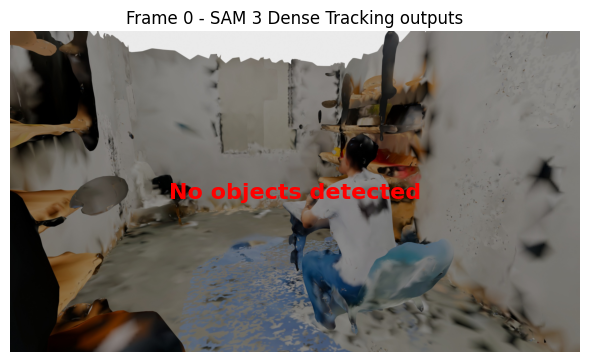

In [12]:
prompt_text_str = ""
frame_idx = 0  # add a text prompt on frame 0
response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        text=prompt_text_str,
    )
)
out = response["outputs"]

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
)

propagate_in_video:   0%|          | 0/200 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

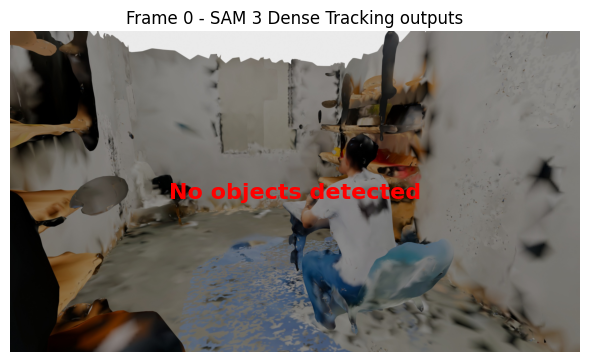

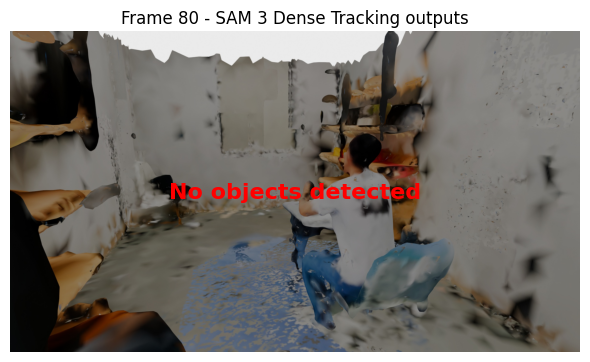

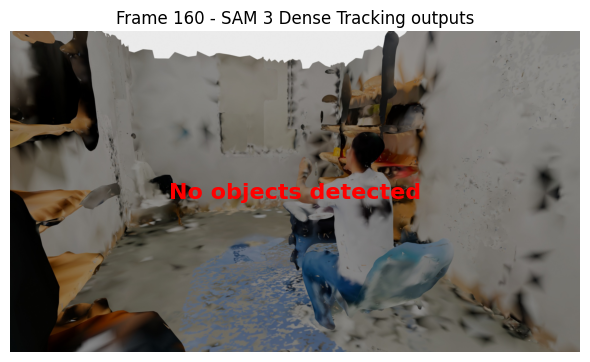

In [13]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 80
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

In [14]:
sample_img = Image.fromarray(load_frame(video_frames_for_vis[0]))

IMG_WIDTH, IMG_HEIGHT = sample_img.size

In [15]:
# For the dancer in the front, suppose now we only want to segment her T-shirt instead of her whole body
# we will use 2 positive clicks and 2 negative clicks to select her shirt.

frame_idx = 10
obj_id = 0
points_abs = np.array(
    [
        [1100, 200],
        [1300, 400],  # positive click
        [1200, 700],
        [1000, 600],

    ]
)
# positive clicks have label 1, while negative clicks have label 0
labels = np.array([1, 1, 1, 1])

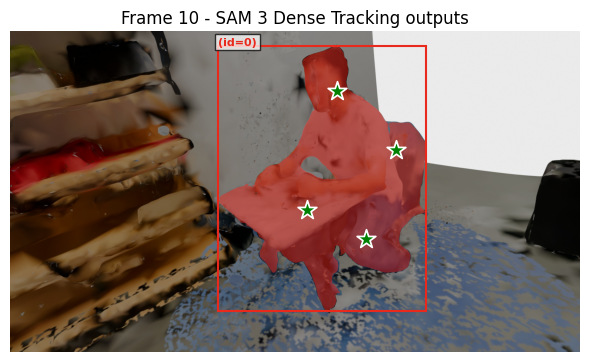

In [24]:
# convert points and labels to tensors; also convert to relative coordinates
points_tensor = torch.tensor(
    abs_to_rel_coords(points_abs, IMG_WIDTH, IMG_HEIGHT, coord_type="point"),
    dtype=torch.float32,
)
points_labels_tensor = torch.tensor(labels, dtype=torch.int32)

response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        points=points_tensor,
        point_labels=points_labels_tensor,
        obj_id=obj_id,
    )
)
out = response["outputs"]

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
    points_list=[points_abs],
    points_labels_list=[labels],
)

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:12<00:00, 15.62it/s]
0it [00:00, ?it/s]


0it [00:00, ?it/s]

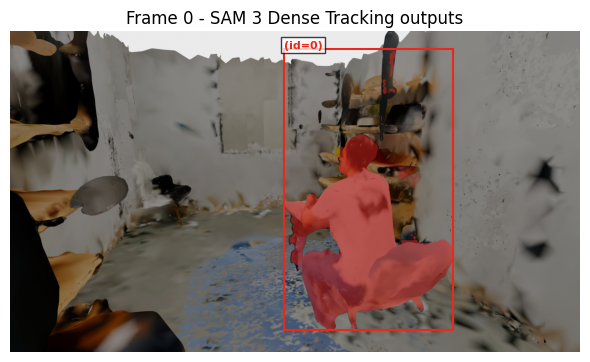

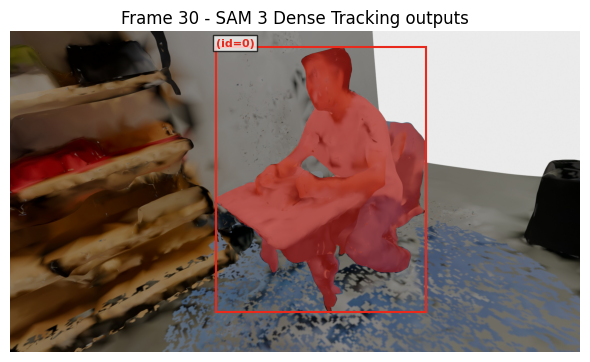

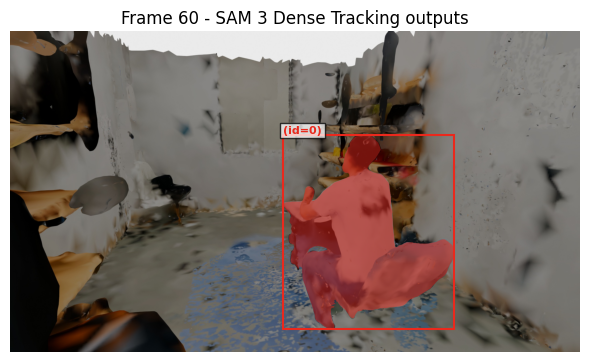

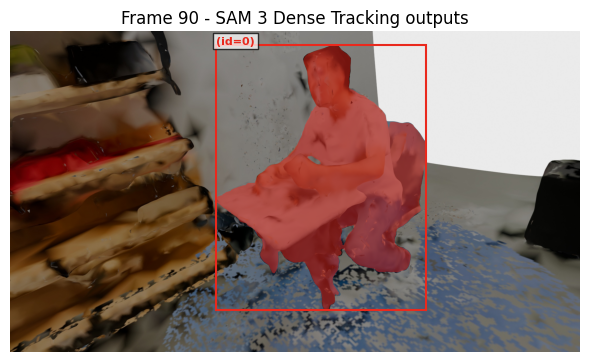

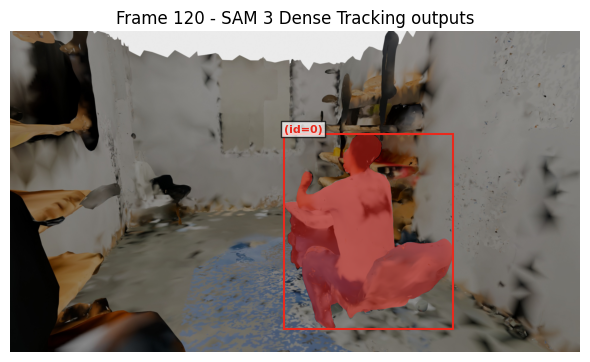

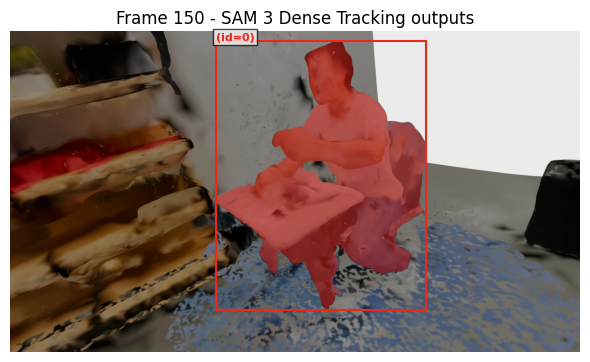

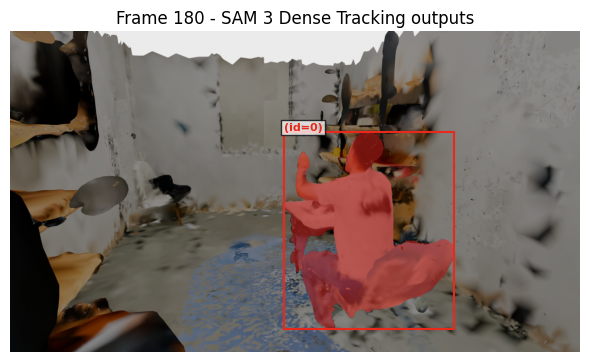

In [25]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 30
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

In [57]:
# finally, close the inference session to free its GPU resources
# (you may start a new session on another video)
_ = predictor.handle_request(
    request=dict(
        type="close_session",
        session_id=session_id,
    )
)

INFO 2026-04-22 13:56:08,302 535741 sam3_video_predictor.py: 250: removed session 34b05ba4-22b6-4d0f-8b09-beceef3d4ee9; live sessions: ['59d336d7-6f6f-4073-ae3a-a984274cd0b9' (160 frames)], GPU memory: 6426 MiB used and 9376 MiB reserved (max over time: 8794 MiB used and 9376 MiB reserved)
INFO 2026-04-22 13:56:08,421 524614 sam3_video_predictor.py: 250: removed session 34b05ba4-22b6-4d0f-8b09-beceef3d4ee9; live sessions: ['59d336d7-6f6f-4073-ae3a-a984274cd0b9' (160 frames)], GPU memory: 6995 MiB used and 10478 MiB reserved (max over time: 9903 MiB used and 10478 MiB reserved)


In [26]:
save_root = f"./data/{dataset}/masks"
save_sam_masks_multi_frames(outputs_per_frame, save_root, num_frames=10, num_views=num_views)

Saved masks to: ./data/answering/masks
Frames: 10, Views/frame: 20, Total saved: 200


In [27]:
mask_root = f"./data/{dataset}/masks"
sam_masks_list = load_masks_for_mesh_frame(mask_root, 0, num_views=20)

In [ ]:
dyn_root = f"./data/{dataset}/meshes/dynamic"
stat_root = f"./data/{dataset}/meshes/static"
gt_root = f"./data/{dataset}/meshes/gt"

os.makedirs(dyn_root, exist_ok=True)
os.makedirs(stat_root, exist_ok=True)
os.makedirs(gt_root, exist_ok=True)

num_frames = 10
viewpoints = [o3d.io.read_pinhole_camera_parameters(f"{out_dir}/view_{i:02d}.json") for i in range(num_views)]
for t in range(num_frames):
    print(f"frame {t}")

    sam_masks_list = load_masks_for_mesh_frame(mask_root, t, num_views=num_views)

    mesh = o3d.io.read_triangle_mesh(os.path.join(out_dir, f"meshes/mesh_{t:02d}.obj"))
    mesh.compute_vertex_normals()

    # save GT
    o3d.io.write_triangle_mesh(os.path.join(gt_root, f"mesh_{t:04d}.obj"), mesh)

    face_mask_t, ratio_t, total_vis_t, unseen_t, low_vis_t = fuse_views_to_face_mask(
        mesh=mesh,
        camera_params_list=viewpoints,
        sam_masks_list=sam_masks_list,
        width=1920,
        height=1080,
        tau=0.8
    )

    neighbors = build_face_adjacency(mesh)

    # Local region only: faces within 1 or 2 mesh-adjacency steps
    # from the initial dynamic region.
    candidate_band = build_local_band_around_dynamic(
        face_is_dynamic=face_mask_t,
        neighbors=neighbors,
        band_iters=10
    )

    # Only consider faces that SAM could not reliably classify.
    expandable = (
        (~face_mask_t)
        & candidate_band
        & (
            (total_vis_t <= 20) |
            (ratio_t >= 0.02)
        )
    )

    face_mask_refined = local_expand_dynamic(
        face_is_dynamic=face_mask_t,
        neighbors=neighbors,
        candidate_band=candidate_band,
        expandable_mask=expandable,
        min_dynamic_neighbors=1,
        num_iters=20
    )

    dyn, stat = split_mesh_by_face_mask(mesh, face_mask_refined)

    # save dynamic
    o3d.io.write_triangle_mesh(os.path.join(dyn_root, f"mesh_{t:04d}.obj"), dyn)

    # save static
    o3d.io.write_triangle_mesh(os.path.join(stat_root, f"mesh_{t:04d}.obj"), stat, write_triangle_uvs=True)